In [1]:
import pandas as pd
import os
from tqdm import tqdm
import csv
root = "../downloads"
files = sorted(os.listdir(root))
histroy = []
start_date = pd.to_datetime("2020-04-12")
FechaNot = "FechaNot"
Fecha_Not = "Fecha Not"

In [2]:
import pandas as pd
import os

def batch_convert_xlsx_to_csv(directory):
    for file in os.listdir(directory):
        if file.endswith('.xlsx'):
            file_path = os.path.join(directory, file)
            csv_path = os.path.join(directory, file.replace('.xlsx', '.csv'))
            df = pd.read_excel(file_path)
            df.to_csv(csv_path, index=False)
            print(f"Converted '{file}' to '{csv_path}'")

# Example usage
batch_convert_xlsx_to_csv("../downloads")

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fdf75f25fd0>>
Traceback (most recent call last):
  File "/home/bxv6gs/.conda/envs/pets/lib/python3.9/site-packages/ipykernel/ipkernel.py", line 770, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


KeyboardInterrupt: 

## Modify Dataset

In [243]:
data = pd.read_csv("../downloads/2020-04-16.csv")

In [244]:
data.loc[data["Fecha de inicio de síntomas"] == "Asintomático", "Fecha de inicio de síntomas"] = \
    data.loc[data["Fecha de inicio de síntomas"] == "Asintomático", "Fecha Not"]

In [245]:
data["Fecha Not"] = data["Fecha de inicio de síntomas"]

In [246]:
data.to_csv("../downloads/2020-04-16.csv")

## Extract

In [2]:
def read_csv_auto_sep_encoding(file_path):
    encodings = ['utf-8-sig', 'ISO-8859-1', 'utf-8']  # Common encodings for Hispanic datasets
    for encoding in encodings:
        try:
            with open(file_path, 'r', encoding=encoding) as file:
                sample = file.read(4096)
                import csv
                try:
                    dialect = csv.Sniffer().sniff(sample)
                    file.seek(0)
                    return pd.read_csv(file_path, sep=dialect.delimiter, encoding=encoding)
                except csv.Error:
                    file.seek(0)
                    return pd.read_csv(file_path, sep=',', encoding=encoding)
        except Exception as e:
            print(f"Failed with encoding {encoding}: {e}")

    raise ValueError("Failed to detect encoding and delimiter.")

for file in (pbar:= tqdm(files)):
    if file.split(".")[-1] != "csv":
        continue
    if file == "2021-03-20.csv":
        break
    # print("current --->", file)
    pbar.set_postfix_str(file)
    try:
        if file.split(".")[-1] == "csv":
            data = read_csv_auto_sep_encoding(os.path.join(root, file))
        elif file.split(".")[-1] == "xlsx":
            data = pd.read_excel(os.path.join(root, file))
        else:
            pass
        end_date = pd.to_datetime(file.split(".")[0])
        full_date_range = pd.date_range(start=start_date, end=end_date)
        result_df = pd.DataFrame({'date': full_date_range})
        result_df[file.split(".")[0] + '_version'] = 0  # Initialize count column to 0
        # Count the number of rows for each date in the data
        
        count = 0
        
        
        if Fecha_Not in data.columns:
            date_column = Fecha_Not
        elif FechaNot in data.columns:
            date_column = FechaNot
        elif "Fecha de diagnóstico" in data.columns:
            date_column = "Fecha de diagnóstico"
            # print("1", file)
        elif "Fecha_diagnostico" in data.columns:
            date_column = "Fecha_diagnostico"
            # print("2", file)
        
            # print("3", file)
        # else:
        #     print(file)
            
        
            # print("4", file)
        
        
        # if count != 1:
        #     print(file)
        #     print(data)
        #     input(0)
        # invalid_rows = data[data[date_column].apply(lambda x: isinstance(x, pd.Timestamp) == False)]
        # print(invalid_rows)
        if '-' in data[date_column][0]:
            data[date_column] = pd.to_datetime(data[date_column].astype(str), format="mixed")
        elif '/' in data[date_column][0]:
            data[date_column] = pd.to_datetime(data[date_column].astype(str), format="mixed", dayfirst=True)
        else:
            print("!!Wrong!!")
            print(data[date_column][0])

        if "nombre_depa" in data.columns:
            city_column = "nombre_depa"
        elif "Departamento_nom" in data.columns:
            city_column = "Departamento_nom"
        elif "Departamento" in data.columns:
            city_column = "Departamento"
        elif "Departamento o Distrito" in data.columns:
            city_column = "Departamento o Distrito"
        elif "Nombre departamento" in data.columns:
            city_column = "Nombre departamento"
        else:
            print(data.head())
            print(data.columns)
            print(data.columns[0])
            print(file)
            continue
        
        bogota_dataset = data[data[city_column].isin(["Bogotá D.C.", "Bogota", "Bogotá", "BOGOTA", "BOGOTÁ D.C.", "Bogotá, D.C.", "Bogotá D C."])]
        if bogota_dataset.shape[0] == 0:
            print(city_column)
            print(data.head(20))
        for date, items in bogota_dataset.groupby([date_column]):
            result_df.loc[result_df['date'] == date[0], file.split(".")[0] + '_version'] = items.shape[0]
        histroy.append({file: result_df})
        del data
    except (ValueError, IsADirectoryError) as e:
        print(e)
        print("Error File: ", file)


  0%|          | 0/358 [00:00<?, ?it/s, 2020-04-12.csv]

 15%|█▍        | 53/358 [00:03<00:33,  9.20it/s, 2020-06-03.csv]/tmp/ipykernel_637479/1417625303.py:11: DtypeWarning: Columns (14,16) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_path, sep=dialect.delimiter, encoding=encoding)
 15%|█▌        | 54/358 [00:03<00:33,  9.00it/s, 2020-06-04.csv]/tmp/ipykernel_637479/1417625303.py:11: DtypeWarning: Columns (14,16) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_path, sep=dialect.delimiter, encoding=encoding)
 15%|█▌        | 55/358 [00:03<00:35,  8.63it/s, 2020-06-05.csv]/tmp/ipykernel_637479/1417625303.py:11: DtypeWarning: Columns (14,16) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_path, sep=dialect.delimiter, encoding=encoding)
 20%|█▉        | 70/358 [00:06<00:55,  5.20it/s, 2020-06-20.csv]/tmp/ipykernel_637479/1417625303.py:11: DtypeWarning: Columns (12,14,16,18,19) have mixed 

Failed with encoding utf-8-sig: 'utf-8' codec can't decode byte 0xd1 in position 683: invalid continuation byte


/tmp/ipykernel_637479/1417625303.py:11: DtypeWarning: Columns (13,14,15,17,19,20,22) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_path, sep=dialect.delimiter, encoding=encoding)
 57%|█████▋    | 203/358 [02:45<06:27,  2.50s/it, 2020-10-30.csv]

Failed with encoding utf-8-sig: 'utf-8' codec can't decode byte 0xd1 in position 671: invalid continuation byte


...

/tmp/ipykernel_637479/1417625303.py:11: DtypeWarning: Columns (13,14,22) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_path, sep=dialect.delimiter, encoding=encoding)
 95%|█████████▍| 339/358 [12:10<01:45,  5.56s/it, 2021-03-18.csv]

Failed with encoding utf-8-sig: 'utf-8' codec can't decode byte 0xd1 in position 671: invalid continuation byte


/tmp/ipykernel_637479/1417625303.py:11: DtypeWarning: Columns (13,14,22) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_path, sep=dialect.delimiter, encoding=encoding)
 95%|█████████▍| 340/358 [12:16<01:40,  5.58s/it, 2021-03-19.csv]

Failed with encoding utf-8-sig: 'utf-8' codec can't decode byte 0xd1 in position 671: invalid continuation byte


/tmp/ipykernel_637479/1417625303.py:11: DtypeWarning: Columns (13,14,22) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(file_path, sep=dialect.delimiter, encoding=encoding)
 95%|█████████▌| 341/358 [12:22<00:37,  2.18s/it, 2021-03-19.csv]


In [9]:
result = pd.DataFrame({"date": [], "count": []})
for file in histroy:
    result_temp = list(file.values())[0]
    # print(result_temp)
    result = pd.merge(result, result_temp, on="date", how='outer')
result

,date,count,2020-04-12_version,2020-04-13_version,2020-04-14_version,2020-04-15_version,2020-04-16_version,2020-04-17_version,2020-04-18_version,2020-04-19_version,...,2021-03-10_version,2021-03-11_version,2021-03-12_version,2021-03-13_version,2021-03-14_version,2021-03-15_version,2021-03-16_version,2021-03-17_version,2021-03-18_version,2021-03-19_version
0,2020-04-12,NaN,0.0,0.0,0.0,8.0,2.0,2.0,7.0,67.0,...,77.0,77.0,77.0,77.0,77.0,77.0,77.0,77.0,77.0,77
1,2020-04-13,NaN,NaN,0.0,0.0,16.0,1.0,1.0,3.0,41.0,...,81.0,81.0,81.0,81.0,81.0,81.0,81.0,81.0,81.0,81
2,2020-04-14,NaN,NaN,NaN,0.0,6.0,1.0,1.0,1.0,12.0,...,57.0,57.0,57.0,57.0,57.0,57.0,57.0,57.0,57.0,57
3,2020-04-15,NaN,NaN,NaN,NaN,3.0,0.0,2.0,2.0,12.0,...,65.0,65.0,65.0,65.0,65.0,65.0,65.0,65.0,65.0,65
4,2020-04-16,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,6.0,...,122.0,122.0,122.0,122.0,122.0,122.0,122.0,122.0,122.0,122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
337,2021-03-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,21.0,307.0,675.0,752
338,2021-03-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,11.0,290.0,733
339,2021-03-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,12.0,314
340,2021-03-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,16


In [6]:
result.shape

(342, 341)

In [18]:
result.to_csv("../Data/Processed/result_2021-03-20.csv")

In [9]:
import matplotlib.pyplot as plt
plt.imshow(pd.read_csv("../Data/Processed/result_2020-9-30.csv", index_col=None).iloc[:, 1:].values == result.values)

ValueError: operands could not be broadcast together with shapes (171,173) (293,291) 

<Axes: >

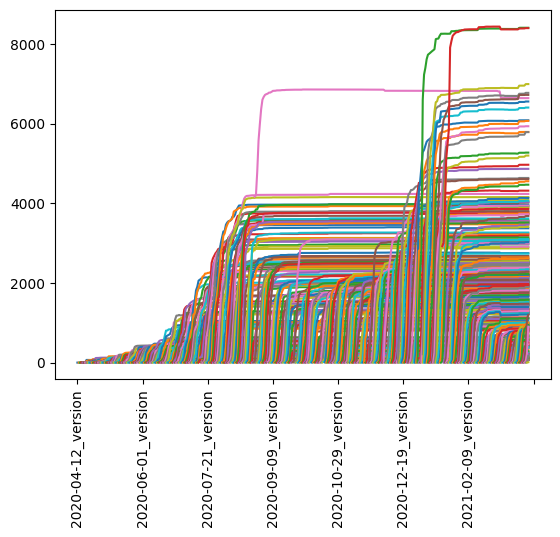

In [6]:
result.iloc[:,2:].T.plot(rot=90, legend=[], linestyle='-')

In [10]:
result.set_index("date", inplace=True)

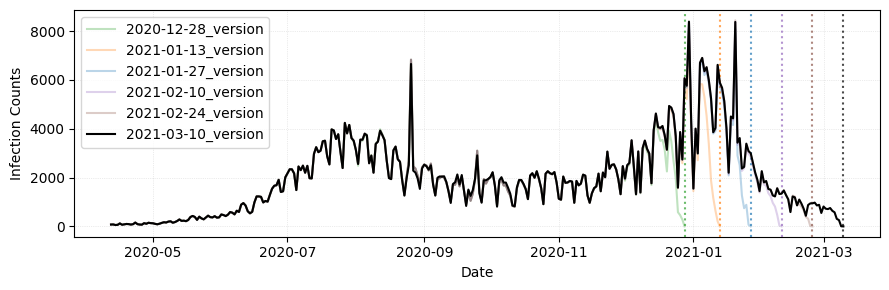

In [12]:
import matplotlib.pyplot as plt
import numpy as np
colors = ['tab:green', 'tab:orange', 'tab:blue', 'tab:purple', 'tab:brown', 'black']

num_lines = result.iloc[:, -80::14].shape[1]

# Define alpha values (e.g., increasing transparency for later sequences)
alphas = [0.3, 0.3, 0.3, 0.3, 0.3, 1]  # Adjust the range as needed
# Select columns to plot
selected_data = result.iloc[:, -80::14]

# Create a figure
fig, ax = plt.subplots(figsize=(9,3))

# Plot each sequence separately with corresponding color and alpha
for idx, (col, color, alpha) in enumerate(zip(selected_data.columns, colors, alphas)):
    ax.plot(selected_data.index, selected_data[col], linestyle='-', color=color, alpha=alpha, label=col)
    # Find the last non-NaN index for this sequence
    last_valid_idx = selected_data[col].last_valid_index()
    
    # Add a vertical dotted line at this position
    if last_valid_idx is not None:
        ax.axvline(x=last_valid_idx, color=color, linestyle='dotted', alpha=0.7)  
# Format the x-axis
plt.xticks()
plt.xlabel("Date")
plt.ylabel("Infection Counts")
plt.legend()
plt.tight_layout()
plt.grid(True, linestyle=':', linewidth=0.5, color='gray', alpha=0.3)
plt.savefig("real_time_viz.pdf")

[-1.62725194  0.40121036  0.07677902  2.27796578  0.18589729 -2.00406814
 -1.87401465  1.78810139 -0.47153711 -0.14837806  0.50017904  0.32382406
  1.11538456 -0.47177671 -0.80243649  0.51155913 -1.0883403  -1.13541997
  0.647265   -1.85423214 -0.6469762   0.36682485 -0.75257432  0.03509272
 -0.3522053   0.60940805  0.99825333  1.77041135 -0.11381418  0.27119869
  1.11655969  1.6775847  -0.27991684  0.59992195  1.20877023  0.4641039
 -2.13844879  1.87952353  0.56982476 -0.81792762 -0.70477936 -0.2076658
 -0.2275528  -0.66180869 -1.12081666  0.32869116 -0.46944178  0.40535449
  1.66598892  0.88201122  0.16460048  2.28039255  0.81610167  0.93491298
 -0.03169532 -0.46488338 -1.02488301  0.30842048  0.76921591 -1.5122669
  1.50432004  1.06301904 -0.62024423  1.22191808 -0.96229951  0.53812576
 -2.05063289  0.12984037 -0.64870011 -1.85238424 -0.4733357  -0.38458702
 -0.05004945 -0.16904764 -0.65609557  0.31696163 -0.19733573  1.20347155
 -0.27511117 -1.09509367 -0.5251739   1.26302704 -1.25

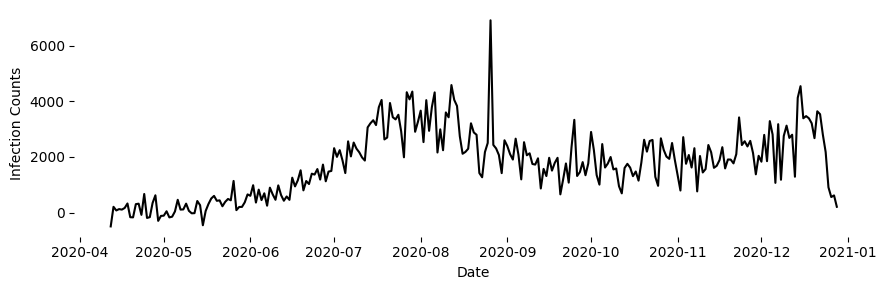

In [37]:
import matplotlib.pyplot as plt
import numpy as np
colors = ['black']

num_lines = result.iloc[:, -80::56].shape[1]

# Define alpha values (e.g., increasing transparency for later sequences)
alphas = [1]  # Adjust the range as needed
# Select columns to plot
selected_data = result.iloc[:, -80::56]

# Create a figure
fig, ax = plt.subplots(figsize=(9,3))

# Plot each sequence separately with corresponding color and alpha
for idx, (col, color, alpha) in enumerate(zip(selected_data.columns, colors, alphas)):
    print(np.random.randn(342, ))
    ax.plot(selected_data.index, selected_data[col] + np.random.randn(342, ) * 300, linestyle='-', color=color, alpha=alpha, label=col)
    # Find the last non-NaN index for this sequence
    last_valid_idx = selected_data[col].last_valid_index()
    
    # Add a vertical dotted line at this position
    # if last_valid_idx is not None:
    #     ax.axvline(x=last_valid_idx, color=color, linestyle='dotted', alpha=0.7)  
# Format the x-axis
plt.xticks()
plt.xlabel("Date")
plt.ylabel("Infection Counts")
# plt.legend()
plt.tight_layout()
# plt.grid(True, linestyle=':', linewidth=0.5, color='gray', alpha=0.3)
plt.box(False)
plt.savefig("real_time_viz.pdf")

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Assume `selected_data` is your time series (from your code)
# Take the last column for forecasting
series = selected_data.iloc[:, -1].dropna()

# Create time index (convert to numeric for regression)
x = np.arange(len(series)).reshape(-1, 1)
y = series.values

# Fit a simple linear model
model = LinearRegression().fit(x, y)

# Forecast next 28 days
future_x = np.arange(len(series), len(series) + 28).reshape(-1, 1)
future_pred = model.predict(future_x)

# Combine original and forecast
forecast_index = pd.date_range(start=series.index[-1], periods=29, freq='D')[1:]
forecast_series = pd.Series(future_pred, index=forecast_index)

# Plot historical + forecast
fig, ax = plt.subplots(figsize=(9,3))
ax.plot(series.index, series, color='black', label='Observed')
# ax.plot(forecast_series.index, forecast_series, color='red', linestyle='--', label='Forecast (28 days)')
ax.legend()
plt.tight_layout()
plt.savefig("real_time_forecast.pdf", bbox_inches='tight')
plt.show()


IndexError: single positional indexer is out-of-bounds

KeyboardInterrupt: 

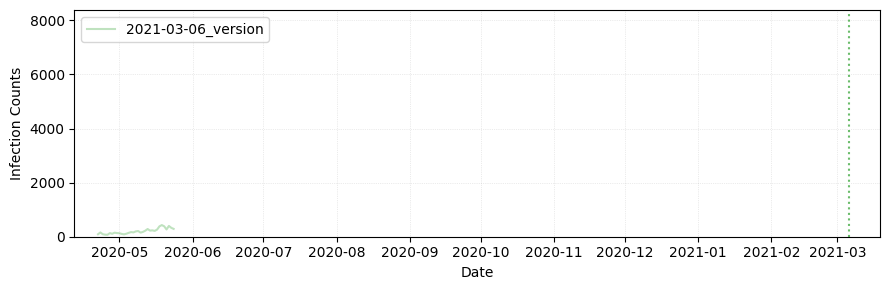

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter

# Data setup
colors = ['tab:green', 'tab:orange', 'tab:blue', 'tab:purple', 'tab:brown', 'black']
alphas = [0.3, 0.3, 0.3, 0.3, 0.3, 1]
selected_data = result.iloc[:, -14::14]
x = selected_data.index
y_data = [selected_data[col].values for col in selected_data.columns]

fig, ax = plt.subplots(figsize=(9, 3))

animated_lines = []
static_lines = []
pause_frames = 50  # 5 seconds at 10 fps
start_frame = 10   # where animation starts on the timeline

# Prepare line handles
for idx, (col, color, alpha) in enumerate(zip(selected_data.columns, colors, alphas)):
    if color == 'black':
        # Black line is static
        line, = ax.plot(x, y_data[idx], color=color, alpha=alpha, label=col)
        static_lines.append(line)
    else:
        # Animated lines, start empty
        line, = ax.plot([], [], color=color, alpha=alpha, label=col)
        animated_lines.append((line, y_data[idx], color, col))

    # Vertical line for last valid point
    last_valid_idx = selected_data[col].last_valid_index()
    if last_valid_idx is not None:
        ax.axvline(x=last_valid_idx, color=color, linestyle='dotted', alpha=0.7)

# Axes settings
ax.set_xlim(x.min(), x.max())
ax.set_ylim(np.nanmin(selected_data.values), np.nanmax(selected_data.values))
plt.xlabel("Date")
plt.ylabel("Infection Counts")
plt.legend()
plt.tight_layout()
plt.grid(True, linestyle=':', linewidth=0.5, color='gray', alpha=0.3)

# Green line (index 0) animates first
frames_per_line = len(x) - start_frame
total_frames = frames_per_line + pause_frames + (len(x) - start_frame)

def update(frame):
    green_line, green_y_vals, _, _ = animated_lines[0]
    other_lines = animated_lines[1:]

    if frame < frames_per_line:
        # Animate green line
        green_line.set_data(x[start_frame:start_frame + frame],
                            green_y_vals[start_frame:start_frame + frame])
        for line, *_ in other_lines:
            line.set_data([], [])  # not started yet
    elif frame < frames_per_line + pause_frames:
        # Pause: green line fully drawn, others hidden
        green_line.set_data(x[start_frame:], green_y_vals[start_frame:])
        for line, *_ in other_lines:
            line.set_data([], [])
    else:
        # Animate the rest simultaneously
        other_frame = frame - (frames_per_line + pause_frames)
        green_line.set_data(x[start_frame:], green_y_vals[start_frame:])
        for line, y_vals, *_ in other_lines:
            line.set_data(x[start_frame:start_frame + other_frame],
                          y_vals[start_frame:start_frame + other_frame])
    return [line for line, *_ in animated_lines]

# Build animation
ani = FuncAnimation(fig, update, frames=total_frames, interval=100, blit=True)

# Save animation
ani.save("real_time_viz.gif", writer=PillowWriter(fps=10))
# ani.save("real_time_viz.mp4", writer='ffmpeg', fps=10)

plt.show()


In [7]:
selected_data[col][selected_data[col] != np.NaN]

date
2020-04-12     77.0
2020-04-13     81.0
2020-04-14     57.0
2020-04-15     65.0
2020-04-16    122.0
              ...  
2021-01-25      NaN
2021-01-26      NaN
2021-01-27      NaN
2021-01-28      NaN
2021-01-29      NaN
Name: 2021-01-20_version, Length: 293, dtype: float64

In [64]:
result

,date,count,2020-04-12_version,2020-04-13_version,2020-04-14_version,2020-04-15_version,2020-04-16_version,2020-04-17_version,2020-04-18_version,2020-04-19_version,...,2020-09-20_version,2020-09-21_version,2020-09-22_version,2020-09-23_version,2020-09-24_version,2020-09-25_version,2020-09-26_version,2020-09-27_version,2020-09-28_version,2020-09-29_version
0,2020-04-12,NaN,0.0,0.0,0.0,8.0,2.0,2.0,7.0,67.0,...,77.0,77.0,77.0,77.0,77.0,77.0,77.0,77.0,77.0,77
1,2020-04-13,NaN,NaN,0.0,0.0,16.0,1.0,1.0,3.0,41.0,...,81.0,81.0,81.0,81.0,81.0,81.0,81.0,81.0,81.0,81
2,2020-04-14,NaN,NaN,NaN,0.0,6.0,1.0,1.0,1.0,12.0,...,57.0,57.0,57.0,57.0,57.0,57.0,57.0,57.0,57.0,57
3,2020-04-15,NaN,NaN,NaN,NaN,3.0,0.0,2.0,2.0,12.0,...,65.0,65.0,65.0,65.0,65.0,65.0,65.0,65.0,65.0,65
4,2020-04-16,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,6.0,...,122.0,122.0,122.0,122.0,122.0,122.0,122.0,122.0,122.0,122
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166,2020-09-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1549.0,1607.0,1818.0,2215.0,2519
167,2020-09-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,44.0,241.0,530
168,2020-09-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,12.0,208
169,2020-09-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,29
